# Mutation data analysis

The VCF File contains results of a study which collected mutation data in a certain population. People contaminated with an illness are marked as *case_x*, whereas healthy people are *control_x*.
---

Steps:

1. How many subjects took part in the study? How many are ill? Healthy?
 
2. How many mutations are observed in the population? Create a table which shows the number of mutations per chromosome. 
   
3. Draw the following histograms, show the data for healthy and ill patients separately  (two histograms on the same graph):  
  3a. Minor allele frequency (MAF) for each mutation in the study  
  3b. Percent of homozygous reference samples for each mutation in the study  
  3c. Percent of homozygous alternative samples for each mutation in the study 
  3d. Percent of heterozygous samples for each mutation in the study    
      
4. Identify the mutations which are statistically related with the illness (p < 0.05,  chi-square test)  
  4a. Apply the chi square test to all mutations in the study  
  4b. Is it necessary to make a correction for multiple testing? If so, explain how and apply it.  
  4c. Draw a Manhattan chart. Make sure that the axes are adequately annotated and that the length along the X axis allocated to each chromosome is proportional to the length of the chromosome.  
  4d. For each mutation that is statistically significantly associated with a given illness determine whether it deviates from the Hardy-Weinberg equilibrium (using the chi-square test). Are there such mutations? Is a correction for multiple testing necessary on this occasion? 

5. Based on a mutation that shows the strongest association with the disease, determine the region on the reference genome where the disease-causing gene is likely to be located.  
  5a. Identify one or more possible genes using the UCSC Genome browser (https://genome.ucsc.edu/cgi-bin/hgGateway?redirect=manual&source=genome.ucsc.edu). The study was performed according to the GRCH37 reference genome.   
  5b. Extract data on diseases related to identified genes from OMIM site (https://omim.org) 

In [1]:
!pip install pysam
!pip install pandas

     |████████████████████████████████| 9.9MB 12.8MB/s 


In [2]:
!gunzip /content/experiment_23.vcf.gz

In [3]:
import pysam
import pandas
import plotly.graph_objects as go

vcf = pysam.VariantFile('/content/experiment_23.vcf')

1. How many subjects took part in the study? How many are ill? Healthy?

In [4]:
case_subjects = 0;
control_subjects = 0;

for subject in list(vcf.header.samples):
  if "case" in subject: case_subjects+=1
  elif "control" in subject: control_subjects+=1

print(case_subjects, control_subjects, case_subjects + control_subjects)

100 100 200


2. How many mutations are observed in the population? Create a table which shows the number of mutations per chromosome

In [5]:
mutations = dict()
cMut = 0

for variant in vcf.fetch():
    cMut += 1
    mutations[variant.chrom] = mutations.get(variant.chrom, 0) + 1

fig = go.Figure(data=[go.Table(header=dict(values=['Hromozom', 'Broj mutacija']),
                  cells=dict(values=[list(mutations.keys()), list(mutations.values())]))
                     ])
fig.show()
print(cMut, mutations)

1340824 {'1': 102842, '2': 114870, '3': 92888, '4': 85336, '5': 86532, '6': 95476, '7': 74003, '8': 76756, '9': 65374, '10': 72903, '11': 67554, '12': 66884, '13': 56428, '14': 44790, '15': 38680, '16': 37876, '17': 30975, '18': 41882, '19': 19172, '20': 33382, '21': 18402, '22': 17819}


3. Draw the following histograms, show the data for healthy and ill patients separately  (two histograms on the same graph):  
  3a. Minor allele frequency (MAF) for each mutation in the study

In [6]:
import numpy as np  
import matplotlib.pyplot as plt

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



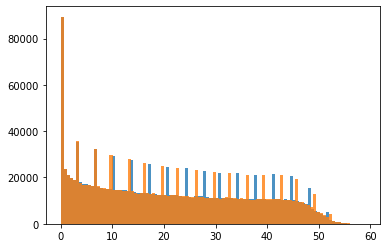

In [7]:
freq_case = dict()
freq_control = dict()

for i, variant in enumerate(vcf.fetch()):
    alt_case = 0
    total_case = 0
    alt_control = 0
    total_control = 0
    for sample in variant.samples:
        for x in variant.samples[sample]['GT']:
            if x == 1:
                if "case" in sample:
                    alt_case += 1
                else: alt_control += 1
        if "case" in sample:
            total_case += 2
        else: total_control += 2

    total = total_case + total_control
    alt = alt_case + alt_control
    ref = total - alt
    rare_case = alt_case if alt < ref else total_case - alt_case
    rare_control = alt_control if alt < ref else total_control - alt_control

    freq_case[i] =  rare_case/(total_case/100) if total_case != 0 else 0
    freq_control[i] = rare_control/(total_control/100) if total_control != 0 else 0

print(freq_case)
print(freq_control)

plt.hist(freq_case.values(), alpha=0.8, bins=100)
plt.hist(freq_control.values(), alpha=0.8, bins=100);

  3b. Percent of homozygous reference samples for each mutation in the study

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



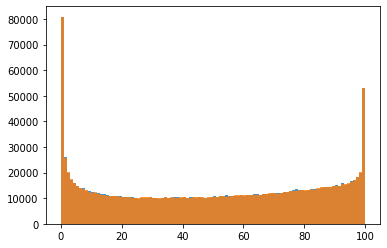

In [8]:
p_homor_case = dict()
p_homor_control = dict()

for i, variant in enumerate(vcf.fetch()):
  homor_case = 0
  total_case = 0
  homor_control = 0
  total_control = 0
  for sample in variant.samples:
    if variant.samples[sample]['GT'][0] == variant.samples[sample]['GT'][1]:
      if variant.samples[sample]['GT'][0] == 0: 
          if "case" in sample:
            homor_case += 1
          else: homor_control += 1
    if "case" in sample:
        total_case += 1
    else: total_control += 1
  if (total_case != 0):
    p_homor_case[i] = homor_case/(total_case/100)
  else:
    p_homor_case[i] = 0
  if (total_control != 0):
    p_homor_control[i] = homor_control/(total_control/100)
  else:
    p_homor_control[i] = 0

print(p_homor_case)
print(p_homor_control)

plt.hist(p_homor_case.values(), alpha=0.8, bins=100)
plt.hist(p_homor_control.values(), alpha=0.8, bins=100);

  3c. Percent of homozygous alternative samples for each mutation in the study

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



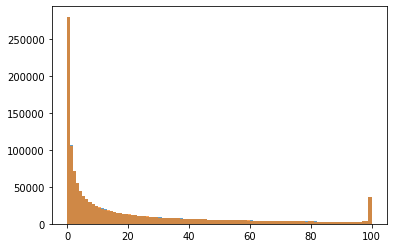

In [10]:
p_homoalt_case = dict()
p_homoalt_control = dict()

for i, variant in enumerate(vcf.fetch()):
  homoalt_case = 0
  total_case = 0
  homoalt_control = 0
  total_control = 0
  for sample in variant.samples:
    if variant.samples[sample]['GT'][0] == variant.samples[sample]['GT'][1]:
      if variant.samples[sample]['GT'][0] == 1: 
          if "case" in sample:
            homoalt_case += 1
          else: homoalt_control += 1
    if "case" in sample:
        total_case += 1
    else: total_control += 1
  if (total_case != 0):
    p_homoalt_case[i] = homoalt_case/(total_case/100)
  else:
    p_homoalt_case[i] = 0
  if (total_control != 0):
    p_homoalt_control[i] = homoalt_control/(total_control/100)
  else:
    p_homoalt_control[i] = 0

print(p_homoalt_case)
print(p_homoalt_control)

plt.hist(p_homoalt_case.values(), alpha=0.7, label='Oboleli', bins=100)
plt.hist(p_homoalt_control.values(), alpha=0.7, label='Zdravi', bins=100);

3d. Percent of heterozygous samples for each mutation in the study  

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



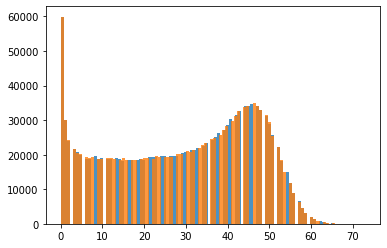

In [11]:
p_hetero_case = dict()
p_hetero_control = dict()

for i, variant in enumerate(vcf.fetch()):
  hetero_case = 0
  total_case = 0
  hetero_control = 0
  total_control = 0
  for sample in variant.samples:
    if variant.samples[sample]['GT'][0] != variant.samples[sample]['GT'][1]:
        if "case" in sample:
            hetero_case += 1
        else: hetero_control += 1
    if "case" in sample:
        total_case += 1
    else: total_control += 1

  if (total_case != 0):
    p_hetero_case[i] = hetero_case/(total_case/100)
  else:
    p_hetero_case[i] = 0
  if (total_control != 0):
    p_hetero_control[i] = hetero_control/(total_control/100)
  else:
    p_hetero_control[i] = 0

print(p_hetero_case)
print(p_hetero_control)

plt.hist(p_hetero_case.values(), alpha = 0.8, bins=100)
plt.hist(p_hetero_control.values(), alpha=0.8, bins=100);

4. Identify the mutations which are statistically related with the illness (p < 0.05,  chi-square test)

4a. Apply the chi-square test to all mutations in the study

<p>

|     | Zdravi  | Oboleli  |
|-----|-------|-------|
| referentni | 15 | 8 |
| alternativni | 6 | 9 |


In [12]:
import scipy
from scipy.stats import chi2_contingency
from scipy.stats import chisquare

chi_results = []
chi_passed = []
cases = {x for x in vcf.header.samples if x.startswith('case')}
controls = {x for x in vcf.header.samples if x.startswith('control')}

for i, variant in enumerate(vcf.fetch()):
    alt_case = sum(1 for sample in cases for gt in variant.samples[sample]['GT'] if gt == 1)
    ref_case = sum(1 for sample in cases for gt in variant.samples[sample]['GT'] if gt == 0)
    alt_control = sum(1 for sample in controls for gt in variant.samples[sample]['GT'] if gt == 1)
    ref_control = sum(1 for sample in controls for gt in variant.samples[sample]['GT'] if gt==0)

    total = alt_case + ref_case + alt_control + ref_control

    if alt_case == 0: alt_case = 1
    if ref_case == 0: ref_case = 1
    if alt_control == 0: alt_control = 1
    if ref_control == 0: ref_control = 1

    square = [alt_case, alt_control,
              ref_case, ref_control] 

    square2 = [[alt_case, alt_control],
              [ref_case, ref_control]]

    ex = [(alt_case+alt_control)*(alt_case + ref_case)/total, (alt_case+alt_control)*(alt_control + ref_control)/total,
          (ref_case+ref_control)*(alt_case + ref_case)/total, (ref_case+ref_control)*(alt_control + ref_control)/total]

    if ex[0] == 0: ex[0] = 1
    if ex[1] == 0: ex[1] = 1
    if ex[2] == 0: ex[2] = 1
    if ex[3] == 0: ex[3] = 1

    #p = scipy.stats.chi2_contingency(square2, correction = False)[1]
    p = scipy.stats.chisquare(square, ex, ddof = 2)[1]

    chi_results.append((variant.chrom, variant.pos, p, variant))

    if p < 0.05:
        chi_passed.append((variant.chrom, variant.pos, p, variant))

print(len(chi_passed))


62388


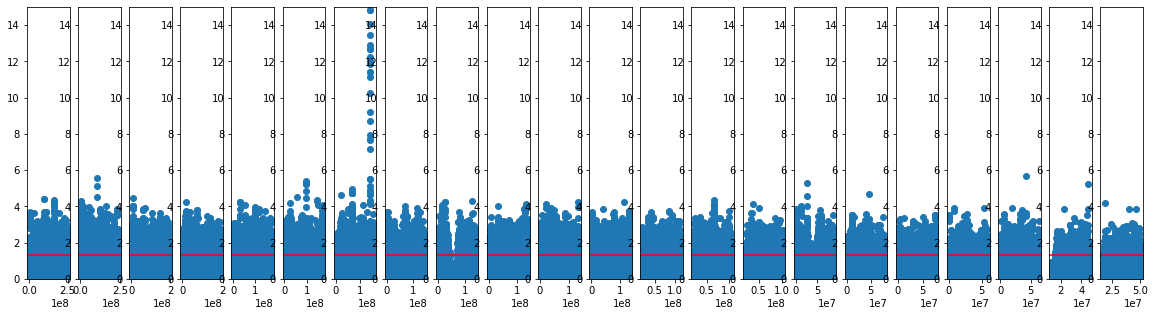

In [ ]:
import matplotlib.pyplot as plt
from itertools import groupby
import numpy as np

results = {key: list(value) for key, value in groupby(chi_results, key=lambda x: x[0])}

fig = plt.figure(figsize=(20, 5))
for i, chrom in enumerate(results):
  ax = fig.add_subplot(1, len(results), i+1)
  pos = [x[1] for x in results[chrom]]
  p = [-np.log10(x[2]) for x in results[chrom]]
  ax.scatter(pos, p)
  ax.set_ylim(0, 15)
  ax.axhline(-np.log10(0.05), c='r')

4b. Is it necessary to make a correction for multiple testing? If so, explain how and apply it.

Even though the p value is low (chance to get this data under the null hypothesis), if we repeat the same procedure for many genes even with a chance that small, the observed data can sometimes be extracted. The simplest solution to the problem of multiple testing is Bonferoni correction which proposes that the p value be multiplied by the number of experiments (that is, to divide the limit for rejecting the null hypothesis by the number of experiments).

In [15]:
bonferoni_passed = [result for result in chi_passed if result[2] < 0.05/cMut]
print("Pre korekcije: ", len(chi_passed))
print("Posle korekcije: ", len(bonferoni_passed))

Pre korekcije:  62388
Posle korekcije:  44


4c. Draw a Manhattan chart. Make sure that the axes are adequately annotated and that the length along the X axis allocated to each chromosome is proportional to the length of the chromosome.

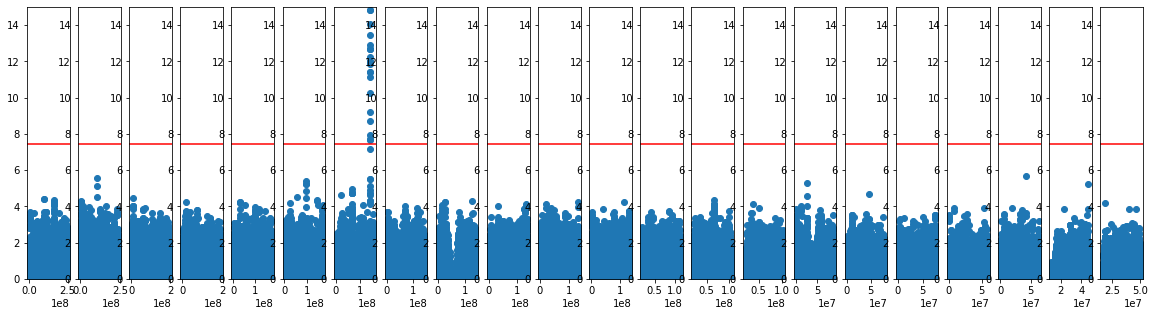

In [ ]:
import matplotlib.pyplot as plt
from itertools import groupby
import numpy as np

results = {key: list(value) for key, value in groupby(chi_results, key=lambda x: x[0])}

fig = plt.figure(figsize=(20, 5))
for i, chrom in enumerate(results):
  ax = fig.add_subplot(1, len(results), i+1)
  pos = [x[1] for x in results[chrom]]
  p = [-np.log10(x[2]) for x in results[chrom]]
  ax.scatter(pos, p)
  ax.set_ylim(0, 15)
  ax.axhline(-np.log10(0.05/cMut), c='r')
  

4d. For each mutation that is statistically significantly associated with a given illness determine whether it deviates from the Hardy-Weinberg equilibrium (using the chi-square test). Are there such mutations? Is a correction for multiple testing necessary on this occasion?

Hardi-Vajnberg ekvilibrijum kaže:
<p>
• Frekvencija AA jedinki će biti:
f(11) = p2
<p>
• Frekvencija BB jedinki će biti:
f(00) = q2
<p>
• Frekvencija AB jedinki će biti:
f(10) = 2pq

In [16]:
from collections import Counter

def hardy_weinberg(variant):
  counts = Counter([sum(sample_content['GT']) for sample_content in variant.samples.values()]) #if None not in sample_content['GT']])
  total = sum(counts.values())
  p = (2*counts[0]+counts[1])/(2*total)
  q = (2*counts[2]+counts[1])/(2*total)

  observed = [counts[0], counts[1], counts[2]]
  f11 = p*p*total
  f10 = 2*p*q*total
  f00 = q*q*total
  expected = [f11, f10, f00]

  return chisquare(observed, expected, ddof=1).pvalue #dof je 1 jer imamo samo 2 promenljive u 3 vrednosti u nizu

#od znacajnih mutacija (posle korekcije) nijedna nije pala hwe 
hwe_fail = [hardy_weinberg(x[3]) < 1e-6 for x in bonferoni_passed]

print(Counter(hwe_fail))

#hwe_passed = [chi for chi, hwe in zip(chi_passed, hwe_fail) if not hwe] 
#results_filtered = {key: list(value) for key, value in groupby(hwe_passed, key=lambda x: x[0])}

Counter({False: 44})


In [17]:
pip install qqman

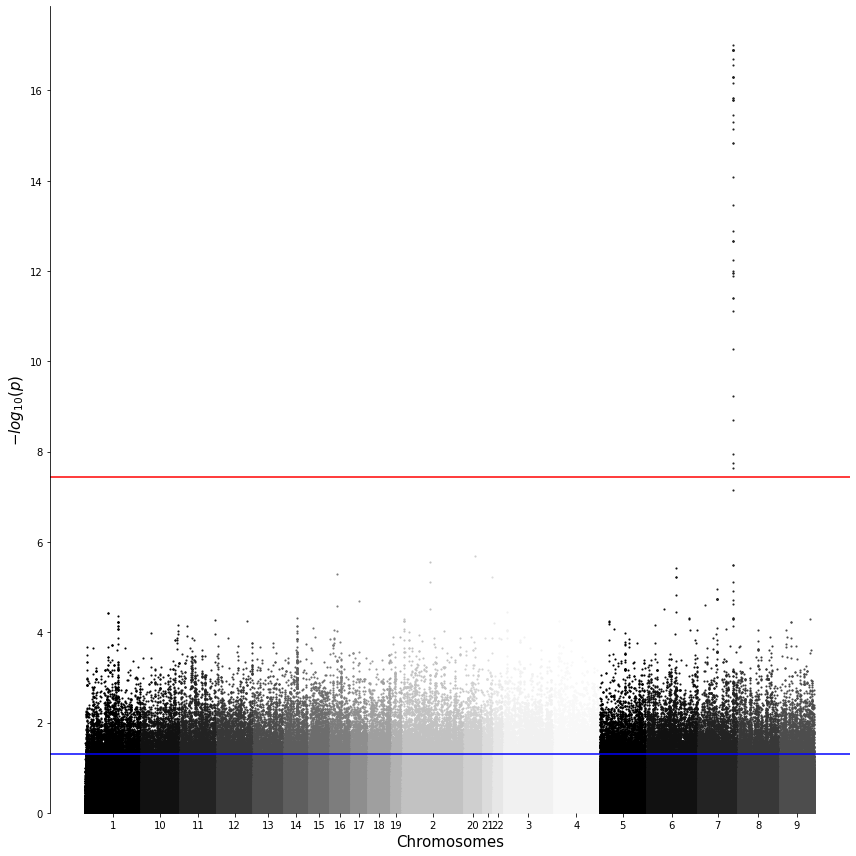

In [18]:
from qqman import qqman
import math
import pandas as pd

d = []
for x in chi_results:
    d.append((x[0], 0, x[2], ""))

df = pd.DataFrame(data=d, columns=['CHR', 'BP', 'P', 'SNP'])
#pandas dataframe chrom basepair pval
qqman.manhattan(df, show=True, cmap_var=17, 
                suggestiveline=-np.log10(0.05),
                genomewideline=-np.log10(0.05/cMut))

In [ ]:
bonferoni_passed

In [20]:
bonferoni_passed = sorted(bonferoni_passed, key=lambda tup: tup[1])
imp_area_len = len(bonferoni_passed)
print("Statisticki znacajno asociran region na referentnom genomu je:\n od ",
    bonferoni_passed[:1],
    " do: ",
    bonferoni_passed[imp_area_len-1:])

Statisticki znacajno asociran region na referentnom genomu je:
 od  [('7', 142508607, 1.9731752900753933e-09, <pysam.libcbcf.VariantRecord object at 0x7feacffe4e10>)]  do:  [('7', 142643676, 5.297322469194025e-11, <pysam.libcbcf.VariantRecord object at 0x7feacffec890>)]


max: 7 17.011958553340154 142577998

[5 bodova] Na osnovu mutacije koja pokazuje najjaču asocijaciju sa bolešću odrediti region na referentnom genomu gde se verovatno nalazi gen koji uzrokuje bolest.
5a. [3 boda] Identifikovati jedan ili više mogućih gena upotrebom UCSC Genome browsera. Studija je rađena prema GRCH37 referentnom genomu.
5b. [2 boda] Izvući podatke o bolestima vezanim za identifikovane gene sa OMIM sajta (nije potrebno prevoditi na srpski jezik).

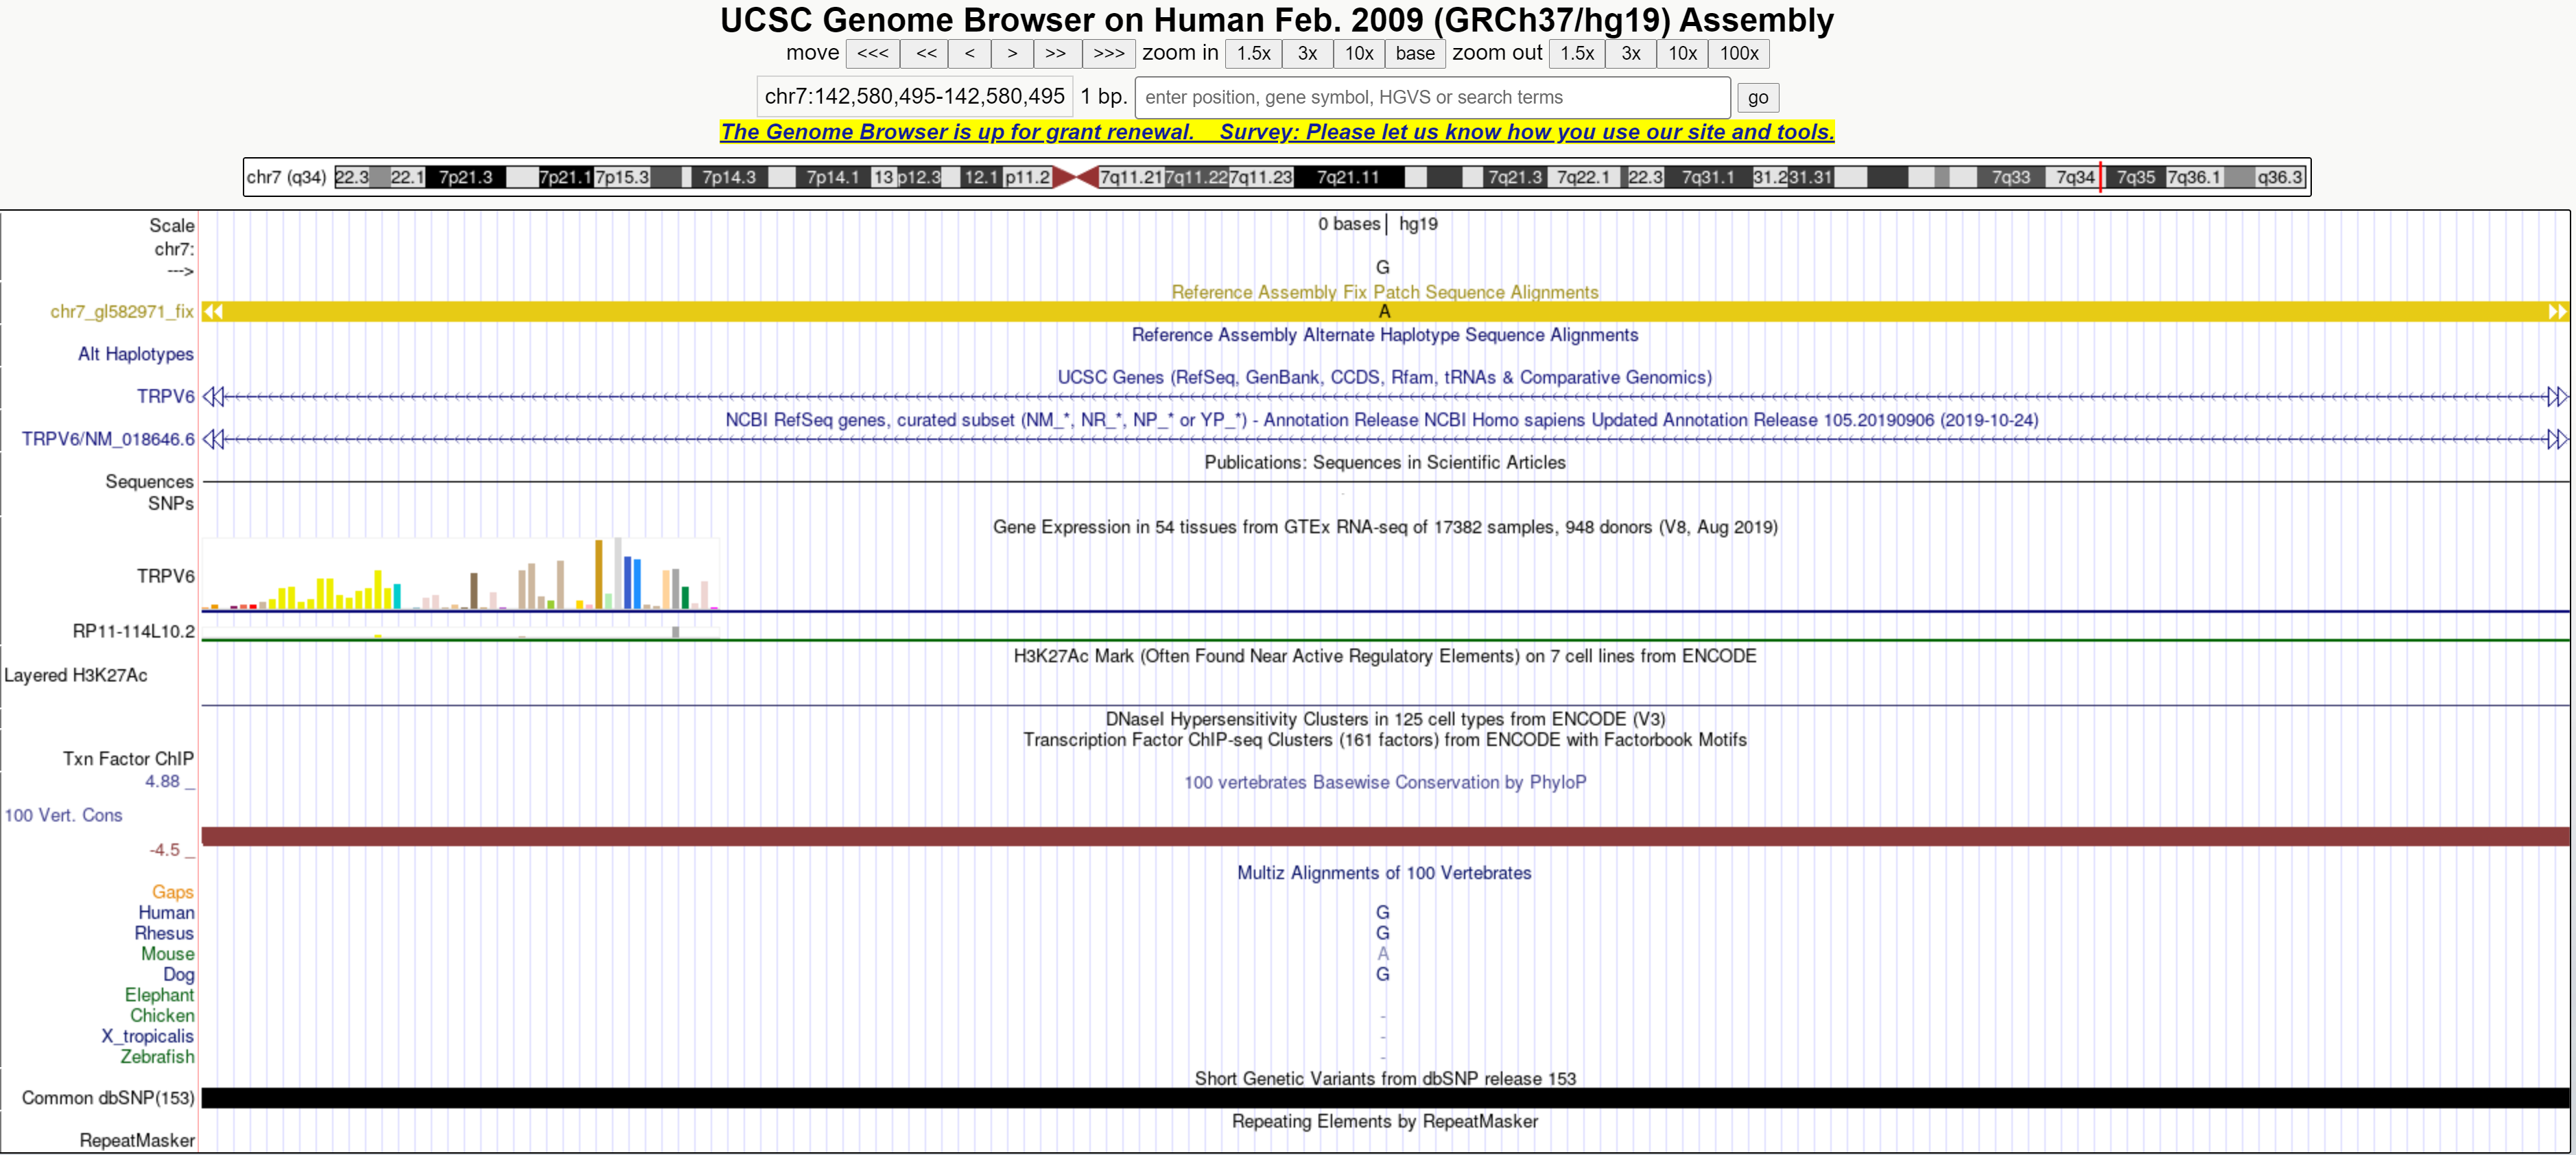

# 618188 HYPERPARATHYROIDISM, TRANSIENT NEONATAL; HRPTTN

A number sign (#) is used with this entry because of evidence that transient neonatal hyperparathyroidism (HRPTTN) is caused by homozygous or compound heterozygous mutation in the TRPV6 (606680) on chromosome 7q34.

Description
Transient neonatal hyperparathyroidism is characterized by interference with placental maternal-fetal calcium transport, causing fetal calcium deficiency resulting in hyperparathyroidism and metabolic bone disease. Because 80% of calcium is transferred during the third trimester, abnormalities may not be detected on second-trimester ultrasounds. Affected infants present at birth with prenatal fractures, shortened ribs, and bowing of long bones, as well as respiratory and feeding difficulties. Postnatal recovery or improvement is observed once calcium is provided orally, with most patients showing complete resolution of skeletal abnormalities by 2 years of age (Suzuki et al., 2018). 

NEPHROLITHIASIS, CALCIUM OXALATE; CAON

Suzuki et al. (2008) suggested that the ancestral RVT haplotype represents a gain-of-function haplotype in TRPV6 and may play a role in increased risk of calcium stone formation. 